# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import pickle

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
# Загрузка данных из parquet файлов

df_tracks = pd.read_parquet("tracks.parquet")
df_catalog = pd.read_parquet("catalog_names.parquet")
df_interactions = pd.read_parquet("interactions.parquet")

In [3]:
# Данные о треках

df_tracks.head()

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


In [4]:
# Каталог треков, альбомов, исполнителей и жанров

df_catalog.head()

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [5]:
# Данные о взаимодействиях пользователей с треками

df_interactions.head()

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [6]:
# Приводим типы данных к нужным для анализа и моделирования
df_tracks["track_id"] = df_tracks["track_id"].astype(int)
df_catalog["id"] = df_catalog["id"].astype(int)
df_interactions["user_id"] = df_interactions["user_id"].astype(int)
df_interactions["track_id"] = df_interactions["track_id"].astype(int)

# Проверяем изменения типов данных
print("Типы данных после изменения:")
print(df_tracks.dtypes)
print(df_catalog.dtypes)
print(df_interactions.dtypes)

# Разделяем каталог на отдельные датафреймы для треков, альбомов, исполнителей и жанров
df_tracks_info = df_catalog[df_catalog["type"] == "track"]
df_albums_info = df_catalog[df_catalog["type"] == "album"]
df_artists_info = df_catalog[df_catalog["type"] == "artist"]
df_genres_info = df_catalog[df_catalog["type"] == "genre"]

Типы данных после изменения:
track_id     int64
albums      object
artists     object
genres      object
dtype: object
id       int64
type    object
name    object
dtype: object
user_id                int64
track_id               int64
track_seq              int16
started_at    datetime64[ns]
dtype: object


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [7]:
# Проверяем наличие пропущенных значений в каждом датафрейме

print("=== Пропущенные значения ===")
print("\ndf_tracks:")
print(df_tracks.isnull().sum())
print(f"Всего строк: {len(df_tracks)}")

print("\ndf_catalog:")
print(df_catalog.isnull().sum())
print(f"Всего строк: {len(df_catalog)}")

print("\ndf_interactions:")
print(df_interactions.isnull().sum())
print(f"Всего строк: {len(df_interactions)}")

=== Пропущенные значения ===

df_tracks:
track_id    0
albums      0
artists     0
genres      0
dtype: int64
Всего строк: 1000000

df_catalog:
id      0
type    0
name    0
dtype: int64
Всего строк: 1812471

df_interactions:
user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64
Всего строк: 222629898


In [8]:
# Проверяем наличие дубликатов в каждом датафрейме
print("=== Дубликаты ===")                                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                                
print(f"\nДубликатов в df_tracks (по track_id): {df_tracks.duplicated(subset=['track_id']).sum()}")                                                                                                                                                            
                                                                                                                                                                                                                                                                
print(f"\nДубликатов в df_catalog (по id и type): {df_catalog.duplicated(subset=['id', 'type']).sum()}")                                                                                                                                                       
print(f"Полных дубликатов в df_catalog: {df_catalog.duplicated().sum()}")
                                                                                                                                                                                                                                                                
print(f"\nДубликатов в df_interactions (по user_id и track_id): {(df_interactions.groupby(['user_id', 'track_id']).size() > 1).sum()}")      

=== Дубликаты ===

Дубликатов в df_tracks (по track_id): 0

Дубликатов в df_catalog (по id и type): 0
Полных дубликатов в df_catalog: 0

Дубликатов в df_interactions (по user_id и track_id): 0


In [9]:
# Проверяем наличие пустых списков в метаданных треков
print("=== Пустые списки метаданных в df_tracks ===")
print(f"Нет информации об альбомах:  {df_tracks['albums'].apply(lambda x: len(x) == 0).sum()}")
print(f"Нет информации об исполнителях: {df_tracks['artists'].apply(lambda x: len(x) == 0).sum()}")
print(f"Нет информации о жанрах:  {df_tracks['genres'].apply(lambda x: len(x) == 0).sum()}")
print()

# Проверяем наличие треков в взаимодействиях, которых нет в df_tracks
interaction_tracks = set(df_interactions['track_id'])
known_tracks = set(df_tracks['track_id'])
missing_in_tracks = interaction_tracks - known_tracks
print(f"=== Проверяем если есть треки в взаимодействиях, которых нет в df_tracks ===")
print(f"Отсутствует: {len(missing_in_tracks)} из {len(interaction_tracks)} уникальных взаимодействий треков")
if missing_in_tracks:
    print(f"Примеры если есть: {list(missing_in_tracks)[:10]}")
print()

=== Пустые списки метаданных в df_tracks ===
Нет информации об альбомах:  18
Нет информации об исполнителях: 15369
Нет информации о жанрах:  3687

=== Проверяем если есть треки в взаимодействиях, которых нет в df_tracks ===
Отсутствует: 0 из 1000000 уникальных взаимодействий треков



In [10]:
# Проверяем наличие треков с неизвестными альбомами, исполнителями и жанрами (те которые не представлены в каталоге)

# Создаем сеты известных ID альбомов, исполнителей и жанров из каталога
known_album_ids = set(df_albums_info["id"])
known_artist_ids = set(df_artists_info["id"])
known_genre_ids = set(df_genres_info["id"])

# Создаем сеты всех ID альбомов, исполнителей и жанров, которые встречаются в df_tracks
all_album_ids = set(id for ids in df_tracks["albums"] for id in ids)
all_artist_ids = set(id for ids in df_tracks["artists"] for id in ids)
all_genre_ids = set(id for ids in df_tracks["genres"] for id in ids)

# Вычисляем неизвестные ID, которые есть в df_tracks, но нет в каталоге
unknown_albums = all_album_ids - known_album_ids
unknown_artists = all_artist_ids - known_artist_ids
unknown_genres = all_genre_ids - known_genre_ids

# Выводим результаты проверки
print(f"Неизвестные альбомы: {len(unknown_albums)} из {len(all_album_ids)}")
print(f"Неизвестные исполнители: {len(unknown_artists)} из {len(all_artist_ids)}")
print(f"Неизвестные жанры: {len(unknown_genres)} из {len(all_genre_ids)}")

Неизвестные альбомы: 0 из 658724
Неизвестные исполнители: 0 из 153581
Неизвестные жанры: 30 из 173


In [11]:
# Подсчитываем сколько треков имеют неизвестные альбомы, исполнителей или жанры

# Подсчитываем количество треков с неизвестными альбомами, исполнителями и жанрами
tracks_unknown_album = df_tracks["albums"].apply(lambda x: bool(set(x) & unknown_albums)).sum()
tracks_unknown_artist = df_tracks["artists"].apply(lambda x: bool(set(x) & unknown_artists)).sum()
tracks_unknown_genre = df_tracks["genres"].apply(lambda x: bool(set(x) & unknown_genres)).sum()

# Выводим результаты
print(f"Треков с неизвестными альбомами: {tracks_unknown_album}")
print(f"Треков с неизвестными исполнителями: {tracks_unknown_artist}")
print(f"Треков с неизвестными жанрами: {tracks_unknown_genre}")

# Создаем датафрейм с треками, которые имеют неизвестные альбомы, исполнителей или жанры
has_unknown_album = df_tracks["albums"].apply(lambda x: bool(set(x) - known_album_ids))                                                       
has_unknown_artist = df_tracks["artists"].apply(lambda x: bool(set(x) - known_artist_ids))                                                    
has_unknown_genre = df_tracks["genres"].apply(lambda x: bool(set(x) - known_genre_ids))

# Объединяем условия для треков с неизвестными данными
df_tracks_unknown = df_tracks[has_unknown_album | has_unknown_artist | has_unknown_genre]                                                     
print(f"Треков с неизвестными данными: {len(df_tracks_unknown)}")                                                                             

# Просматриваем примеры треков с неизвестными данными
df_tracks_unknown.head()

Треков с неизвестными альбомами: 0
Треков с неизвестными исполнителями: 0
Треков с неизвестными жанрами: 48345
Треков с неизвестными данными: 48345


,track_id,albums,artists,genres
36,436,[36],[330],"[28, 164]"
59,594,"[54, 88, 5479, 5785124, 9198099, 9231427, 1088...",[533],"[28, 162]"
125,1025,"[94, 2325, 8757, 8986, 318695, 17004129]",[937],"[28, 162]"
126,1026,"[94, 780, 8727]",[937],"[28, 162]"
128,1028,"[94, 4865, 19666753, 19666891]",[936],"[28, 162]"


In [12]:
# Для треков с неизвестными данными, заменим неизвестные ID на специальный ID для "Unknown" и добавим его в каталог

# Создаем специальный ID для "Unknown"
DUMMY_UNKNOWN_ID = -1                                                                          

# Заменяем неизвестные ID жанров (те которые не представлены в каталоге) 
df_tracks["genres"] = df_tracks["genres"].apply(
    lambda x: [g if g in known_genre_ids else DUMMY_UNKNOWN_ID for g in x]                                                                    
)                                                                                                                                             
# Убираем дубликаты жанров после замены
df_tracks["genres"] = df_tracks["genres"].apply(lambda x: list(dict.fromkeys(x)))

# Заполняем пустые исполнители                                                                                                                                                                                                                                         
df_tracks["artists"] = df_tracks["artists"].apply(                                                                                                                                                                                                             
    lambda x: x if len(x) > 0 else [DUMMY_UNKNOWN_ID]                                                                                                                                                                                                         
)

# Заполняем пустые альбомы
df_tracks["albums"] = df_tracks["albums"].apply(
    lambda x: x if len(x) > 0 else [DUMMY_UNKNOWN_ID]                                                                                                                                                                                                          
)
                                                                                                                                                                                                                                                                
# Заполняем пустые жанры
df_tracks["genres"] = df_tracks["genres"].apply(
    lambda x: x if len(x) > 0 else [DUMMY_UNKNOWN_ID]
)

# Добавляем "Unknown" в каталог жанров
df_genres_info = pd.concat([                                                                                                                  
    df_genres_info,                                                                                                                           
    pd.DataFrame({"id": [DUMMY_UNKNOWN_ID], "type": ["genre"], "name": ["Unknown"]})
], ignore_index=True)

# Добавляем "Unknown" в каталог исполнителей и альбомов
df_artists_info = pd.concat([                                                                                                                                                                                                                                  
    df_artists_info,                                                                                                                                                                                                                                           
    pd.DataFrame({"id": [DUMMY_UNKNOWN_ID], "type": ["artist"], "name": ["Unknown"]})                                                                                                                                                                         
], ignore_index=True)                                                                                                                                                                                                                                          

# Добавляем "Unknown" в каталог альбомов
df_albums_info = pd.concat([                                                                                                                                                                                                                                   
    df_albums_info,                                                                                                                                                                                                                                            
    pd.DataFrame({"id": [DUMMY_UNKNOWN_ID], "type": ["album"], "name": ["Unknown"]})                                                                                                                                                                           
], ignore_index=True)   

# Подсчитываем сколько всего треков с Unknown жанром после замены (те которые были с неизвестными жанрами и те которые были с пустыми жанрами)
print(f"Треков с неизвестным жанром: {df_tracks['genres'].apply(lambda x: DUMMY_UNKNOWN_ID in x).sum()}")

# Проверяем что после замены неизвестных жанров на "Unknown" не осталось треков с неизвестными жанрами (те которые не представлены в каталоге)
known_genre_ids = set(df_genres_info["id"])
all_genre_ids = set(id for ids in df_tracks["genres"] for id in ids)
unknown_genres = all_genre_ids - known_genre_ids
print(f"Неизвестные жанры: {len(unknown_genres)} из {len(all_genre_ids)}")

Треков с неизвестным жанром: 52032
Неизвестные жанры: 0 из 144


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.



По первому знакомству с данными могу сказать что данные состоят из трёх источников: метаданные треков, каталог названий треков, альбомов и жанров и взаимодействия пользователей с треками с порядковым номером взаимодействия и датой.

В ходе анализа я могу выделить следующие явные наблюдения и проблемы:
1. Пропущенных значений (NaN) в датафреймах нет, дубликатов так же нет.
2. У некоторых треков может отсутсвовать информация об исполнителях, жанрах или альбомах. Больше всего строк не имеют информации об исполнителях - около 15 тысяч.
3. Около 30 из 173 уникальных жанров, встречающихся в метаданных треков, отсутствуют в каталоге названий. Это затрагивает ~ 48 тысяч треков.
4. 849 пользователей имеют только одно взаимодействие - это может быть проблемой с точки зрения рекомендательной системы.
5. Распределение прослушиваний сильно скошено вправо, при чем медиана — 55 треков, среднее — 162, максимум — 16 637. Топ-1% пользователей (>1 576 треков) создают непропорционально большую долю событий (возможно боты или аномальные аккаунты).

Основываясь на находках я предпринял следующие корректирующие действия:
1. Привел типы данных к стандартизированному формату - int64 для ID и datetime для дат.
2. Разделил для удобства каталог на отдельные справочники - треки, альбомы, исполнители, и жанры.
3. Неизвестные жанры (Которые отсутствовали в каталоге) а так же пустые списки исполнителей, альбомов и жанров заменил на специальный ID (-1, или "Unknown"). Так же добавил соответствующую запись в каждый справочник.
4. Отфильтровал пользователей с менее чем 2 взаимодействиями (всего 849 пользователей, что менее 1%)
5. Для каждого пользователя оставили только последние N треков, где N равно 99-му процентилю распределения количества треков по всем пользователям, чтобы ограничить влияние аномально активных пользователей.
6. Подготовленные данные сохранил в формате parquet для дальнейшего моделирования.

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

=== Распределение количества прослушанных треков по пользователям ===
count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
Name: track_id, dtype: float64



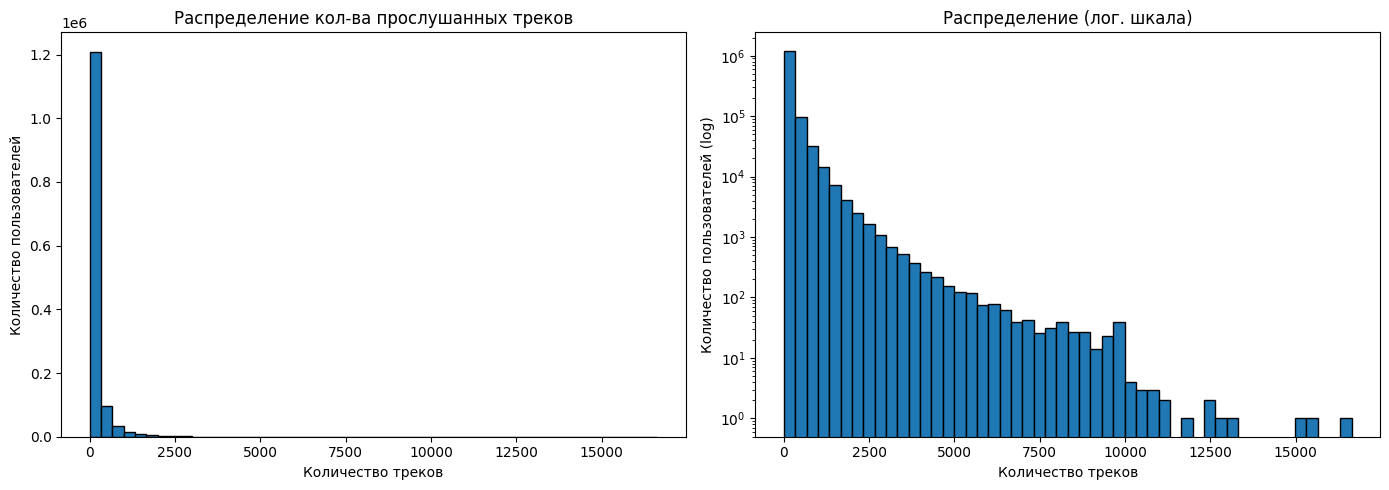

In [ ]:
# Проверим распределение количества прослушанных треков по пользователям ДО фильтрации

# Подсчитываем количество треков, с которыми взаимодействовал каждый пользователь
tracks_per_user = df_interactions.groupby("user_id")["track_id"].count()

# Выводим статистику по количеству событий на пользователя
print("=== Распределение количества прослушанных треков по пользователям ===")
print(tracks_per_user.describe())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения количества прослушанных треков на линейной шкале
axes[0].hist(tracks_per_user, bins=50, edgecolor="black")
axes[0].set_title("Распределение кол-ва прослушанных треков")
axes[0].set_xlabel("Количество треков")
axes[0].set_ylabel("Количество пользователей")

# Гистограмма распределения количества прослушанных треков на логарифмической шкале
axes[1].hist(tracks_per_user, bins=50, edgecolor="black", log=True)
axes[1].set_title("Распределение (лог. шкала)")
axes[1].set_xlabel("Количество треков")
axes[1].set_ylabel("Количество пользователей (log)")

plt.tight_layout()
plt.show()
plt.close()

In [14]:
# Проверяем количество ивентов на пользователя и фильтруем пользователей с менее чем 2 событиями

tracks_per_user = df_interactions.groupby("user_id")["track_id"].count()

# Выводим статистику по количеству событий на пользователя
print(f"Users with 1 event: {(tracks_per_user == 1).sum()}")                                                                                                                                                                                                   
print(f"Users with 2+ events: {(tracks_per_user >= 2).sum()}")                                                                                                                                                                                                 
print(f"Min events per user: {tracks_per_user.min()}")    
rows_before = len(df_interactions)
print(f"Rows before: {rows_before}")                                                                                                                                                                   

# Оставляем только пользователей с 2 и более событиями
valid_users = tracks_per_user[tracks_per_user >= 2].index                                                                                                                                                                                                      
df_interactions = df_interactions[df_interactions["user_id"].isin(valid_users)]                                                                                                                                                                                

# Проверяем сколько строк осталось после фильтрации и какую пропорцию от изначального количества данных это составляет
rows_after = len(df_interactions)
print(f"Rows after: {len(df_interactions)}")
print(f"Proportion kept ~: {rows_after / rows_before * 100:.2f}%")

Users with 1 event: 849
Users with 2+ events: 1372372
Min events per user: 1
Rows before: 222629898
Rows after: 222629049
Proportion kept ~: 100.00%


In [15]:
# Проверяем наличие аномальных пользователей с очень большим количеством взаимодействий (возможно боты или аномальные пользователи)

try:
    n_before = len(df_interactions)
    df_interactions = pd.read_parquet("interactions_threshold_filtered.parquet")

except FileNotFoundError:
    # Выводим статистику по количеству треков на пользователя
    percentiles = tracks_per_user.quantile([0.95, 0.99, 0.999, 1.0])                                                                                                                                                                                             
    print("=== Треков на пользователя про процентилям ===")                                                                                                                                                                                                                   
    print(percentiles)                                                                                                                                                                                                                                             
    print(f"\nСредняя: {tracks_per_user.mean():.1f}")                                                                                                                                                                                                                 
    print(f"Медиана: {tracks_per_user.median():.1f}")                                                                                                                                                                                                               

    # Устанавливаем порог на 99-м процентиле и оставляем каждому пользователю не более этого количества треков, чтобы избежать влияния аномальных пользователей с огромным количеством взаимодействий
    threshold = tracks_per_user.quantile(0.99)                                                                                                                                                                                                                     
    print(f"\nПорог 99-го процентиля: {threshold}")                                                                                                                                                                                                             

    # Проверяем сколько строк осталось после фильтрации и какую пропорцию от изначального количества данных это составляет
    n_before = len(df_interactions)                                                                                                                                                                                                                                
    normal_users = tracks_per_user[tracks_per_user <= threshold].index                                                                                                                                                                                             
    df_interactions = (                                                                                                                                                         
        df_interactions                                                                                                                                                           
        .sort_values("track_seq", ascending=False)
        .groupby("user_id")                                                                                                                                                       
        .head(threshold)
        .sort_values(["user_id", "track_seq"])                                                                                                                                    
        .reset_index(drop=True)                                                                                                                                                   
    )

    df_interactions.to_parquet("interactions_threshold_filtered.parquet", index=False)
                                                                                                                                                                                                                                                                
print(f"Строк до: {n_before}")                                                                                                                                                                                                                              
print(f"Строк после:  {len(df_interactions)}")                                                                                                                                                                                                                  
print(f"Оставленная пропорция: {len(df_interactions) / n_before * 100:.2f}%")

Строк до: 222629049
Строк после:  208452379
Оставленная пропорция: 93.63%


=== Распределение количества прослушанных треков по пользователям ===
count    1.372372e+06
mean     1.518920e+02
std      2.565578e+02
min      2.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.576000e+03
Name: track_id, dtype: float64



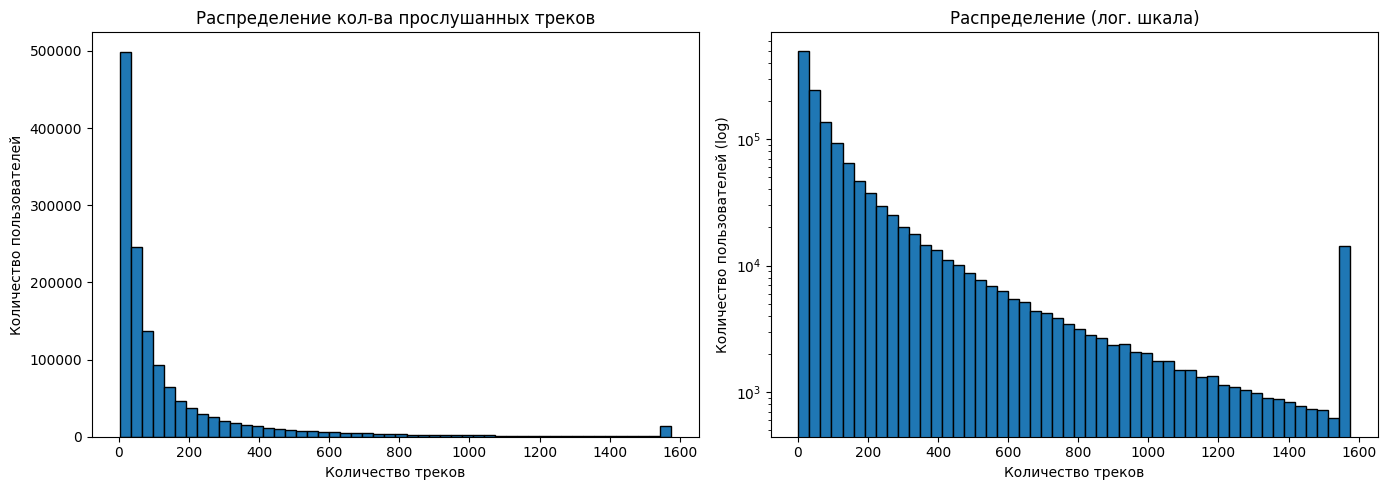

In [ ]:
# Проверим распределение количества прослушанных треков по пользователям ПОСЛЕ фильтрации

# Подсчитываем количество треков, с которыми взаимодействовал каждый пользователь
tracks_per_user = df_interactions.groupby("user_id")["track_id"].count()

# Выводим статистику по количеству событий на пользователя
print("=== Распределение количества прослушанных треков по пользователям ===")
print(tracks_per_user.describe())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма распределения количества прослушанных треков на линейной шкале
axes[0].hist(tracks_per_user, bins=50, edgecolor="black")
axes[0].set_title("Распределение кол-ва прослушанных треков")
axes[0].set_xlabel("Количество треков")
axes[0].set_ylabel("Количество пользователей")

# Гистограмма распределения количества прослушанных треков на логарифмической шкале
axes[1].hist(tracks_per_user, bins=50, edgecolor="black", log=True)
axes[1].set_title("Распределение (лог. шкала)")
axes[1].set_xlabel("Количество треков")
axes[1].set_ylabel("Количество пользователей (log)")

plt.tight_layout()
plt.show()
plt.close()

In [17]:
# Проверяем диапазон дат в данных о взаимодействиях и наличие аномальных дат (например, будущих дат или дат слишком ранних)
print("=== Диапазон дат ===") 
print(f"Минимальная: {df_interactions['started_at'].min()}")                                                                                                                                                                                                      
print(f"Максимальная: {df_interactions['started_at'].max()}")
                                                                                                                                                                                                                                                                
# Распределение событий по месяцам, чтобы заметить аномалии в датах (например, если есть события в будущем или слишком ранние)                                                                                                                                                                                                                     
print("\n=== Ивентов по месяцам ===")                                                                                                                                                                                                                            
print(df_interactions['started_at'].dt.to_period('M').value_counts().sort_index())                                                                                                                                                                             
                                                                                                                                                                                                                                                            
# Проверяем наличие событий за пределами ожидаемого диапазона (например, до 2022 года или после 2022 года)                                                                                                                                                                                                             
date_min = pd.Timestamp("2022-01-01")                                                                                                                                                                                                                        
date_max = pd.Timestamp("2022-12-31")                                                                                                                                                                                                                          
                                                                                                                                                                                                                                                            
outlier_dates = df_interactions[                                                                                                                                                                                                                               
    (df_interactions['started_at'] < date_min) |                                                                                                                                                                                                             
    (df_interactions['started_at'] > date_max)                                                                                                                                                                                                                 
]
print(f"\nСобытий вне диапазона {date_min.date()} — {date_max.date()}: {len(outlier_dates)}")                                                                                                                                                                         

# Если есть аномальные даты, выводим их статистику и удаляем эти строки из данных о взаимодействиях
if len(outlier_dates) > 0:                                                                                                                                                                                                                                     
    print(outlier_dates['started_at'].describe())                                                                                                                                                                                                              
                                                                                                                                                                                                                                                                
    # Удаляем строки с аномальными датами и проверяем сколько строк осталось после фильтрации
    n_before = len(df_interactions)                                                                                                                                                                                                                            
    df_interactions = df_interactions[                                                                                                                                                                                                                         
        (df_interactions['started_at'] >= date_min) &                                                                                                                                                                                                          
        (df_interactions['started_at'] <= date_max)                                                                                                                                                                                                            
    ]                                                                                                                                                                                                                                                          
    print(f"\nСтрок до фильтрации: {n_before}")                                                                                                                                                                                                                      
    print(f"Строк после фильтрации:  {len(df_interactions)}")
    print(f"Пропорционально оставили: {len(df_interactions) / n_before * 100:.2f}%")                                                                                                                                                                                    
else:
    print("Нет аномальных дат — фильтрация не требуется.")

=== Диапазон дат ===
Минимальная: 2022-01-01 00:00:00
Максимальная: 2022-12-31 00:00:00

=== Ивентов по месяцам ===
started_at
2022-01     1169160
2022-02     2921493
2022-03     5529100
2022-04     7926373
2022-05    11226670
2022-06    14267937
2022-07    18907910
2022-08    23280799
2022-09    26578268
2022-10    31642083
2022-11    33958923
2022-12    31043663
Freq: M, Name: count, dtype: int64

Событий вне диапазона 2022-01-01 — 2022-12-31: 0
Нет аномальных дат — фильтрация не требуется.


Наиболее популярные треки

=== Топ-20 популярных треков ===
 track_id  listen_count              track_name
 33311009        105412                Believer
    53404        103870 Smells Like Teen Spirit
 35505245         98258              I Got Love
   178529         95833                    Numb
 65851540         86574                  Юность
 51241318         84721              In The End
 32947997         84691            Shape of You
 45499814         84316                    Life
 60292250         84258         Blinding Lights
 24692821         83926          Way Down We Go
 39257277         81112              In My Mind
   795836         80800       Shape Of My Heart
 29544272         79348                   Human
  6705392         78919       Seven Nation Army
 51516485         78002                 bad guy
 47627256         75489                 Cradles
  2758009         74762     The Show Must Go On
 57921154         74518                  Комета
 49961817         74313           Грустный дэнс
    373

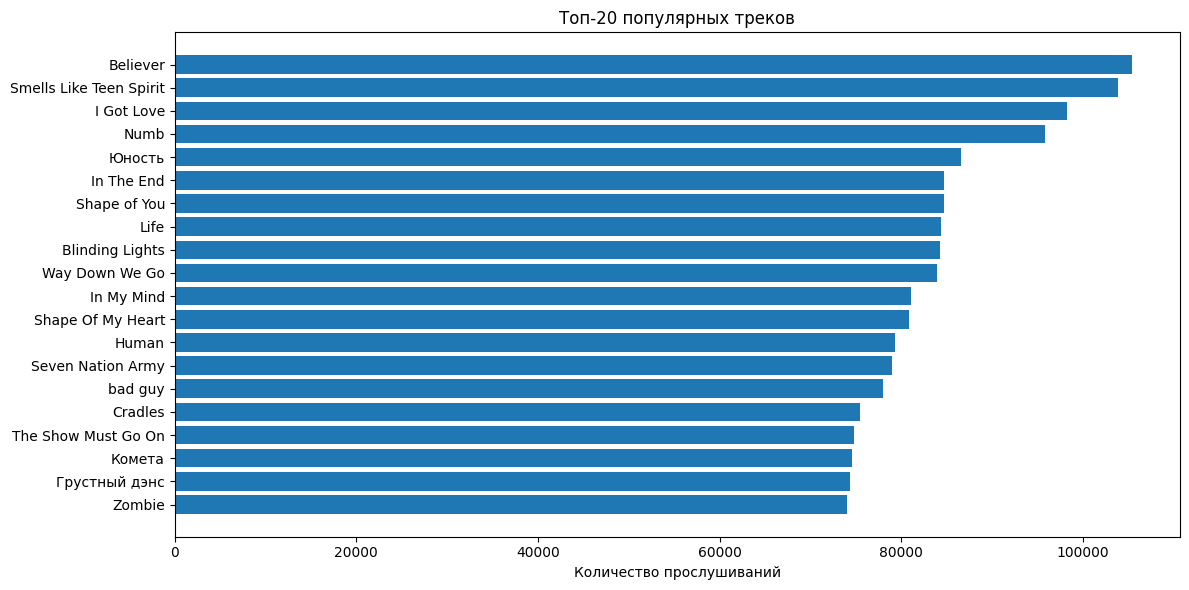

In [ ]:
# --- 2. Наиболее популярные треки ---
track_listen_counts = df_interactions.groupby("track_id")["user_id"].count().reset_index()
track_listen_counts.columns = ["track_id", "listen_count"]
track_listen_counts = track_listen_counts.sort_values("listen_count", ascending=False)

# Добавим имена треков
track_names = df_tracks_info.rename(columns={"id": "track_id", "name": "track_name"})[["track_id", "track_name"]]
top_tracks = track_listen_counts.head(20).merge(track_names, on="track_id", how="left")

# Выводим топ-20 популярных треков
print("=== Топ-20 популярных треков ===")
print(top_tracks.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 6))
labels = top_tracks.apply(lambda r: f"{r['track_name']}" if pd.notna(r['track_name']) else str(r['track_id']), axis=1)
ax.barh(labels[::-1], top_tracks["listen_count"][::-1])
ax.set_xlabel("Количество прослушиваний")
ax.set_title("Топ-20 популярных треков")
plt.tight_layout()
plt.show()
plt.close()

Наиболее популярные жанры

=== Топ-20 популярных жанров ===
 genre_id  listen_count  genre_name
       11      52731289         pop
       75      36115446         rap
      102      28366490     allrock
       20      25968834      ruspop
        3      24444921      rusrap
       68      18807840 electronics
       16      15661748       dance
        2      12315126     rusrock
       14      11399167        rock
       44      11380490  foreignrap
       47      10858816       metal
       70       9421332       indie
       13       9234389 alternative
       -1       6785954     Unknown
      325       6441202     estrada
       25       5460133  soundtrack
       19       4684696  rusestrada
        6       3913944 local-indie
       21       3736514        folk
       50       3446121        punk



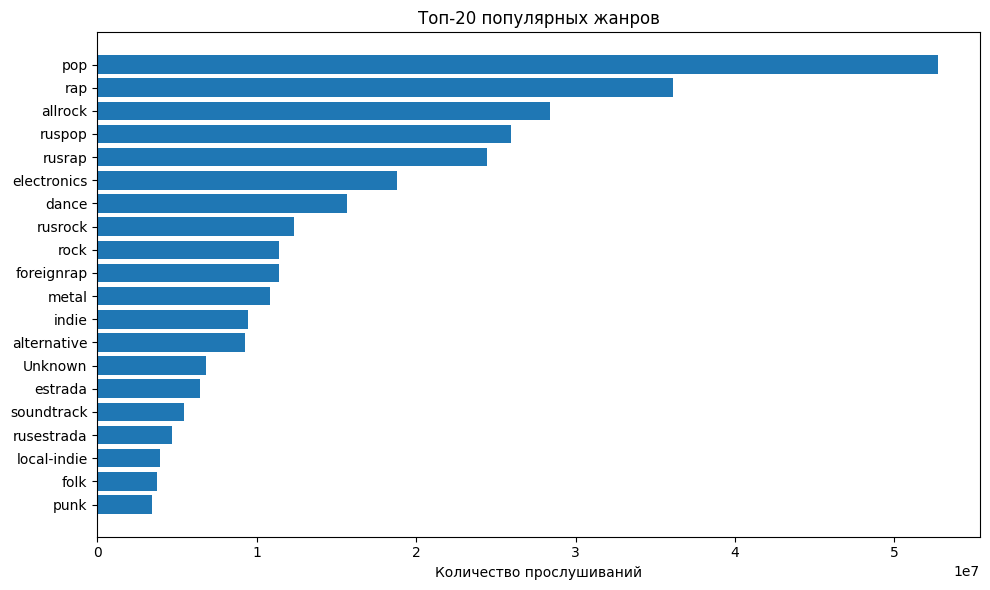

In [ ]:
# --- 3. Наиболее популярные жанры ---

# Раскроем жанры: каждый трек может иметь несколько жанров
track_genres = df_tracks.explode("genres")[["track_id", "genres"]].rename(columns={"genres": "genre_id"})
# Присоединим прослушивания
genre_listens = track_genres.merge(df_interactions[["track_id"]], on="track_id")
genre_listen_counts = genre_listens.groupby("genre_id").size().reset_index(name="listen_count")
genre_listen_counts = genre_listen_counts.sort_values("listen_count", ascending=False)

# Добавим имена жанров
genre_names = df_genres_info.rename(columns={"id": "genre_id", "name": "genre_name"})[["genre_id", "genre_name"]]
top_genres = genre_listen_counts.head(20).merge(genre_names, on="genre_id", how="left")

# Выводим топ-20 популярных жанров
print("=== Топ-20 популярных жанров ===")
print(top_genres.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_genres["genre_name"][::-1], top_genres["listen_count"][::-1])
ax.set_xlabel("Количество прослушиваний")
ax.set_title("Топ-20 популярных жанров")
plt.tight_layout()
plt.show()
plt.close()

Треки, которые никто не прослушал

In [20]:
# --- 4. Треки, которые никто не прослушал ---

# Получаем множества треков, которые были прослушаны и все треки из каталога
listened_track_ids = set(df_interactions["track_id"])
all_track_ids = set(df_tracks["track_id"])
unlistened_track_ids = all_track_ids - listened_track_ids

# Выводим статистику по трекам, которые никто не прослушал
print("=== Треки, которые никто не прослушал ===")
print(f"Всего треков: {len(all_track_ids)}")
print(f"Прослушанных треков: {len(listened_track_ids)}")
print(f"Непрослушанных треков: {len(unlistened_track_ids)}")
print(f"Доля непрослушанных: {len(unlistened_track_ids) / len(all_track_ids) * 100:.1f}%")
print()

=== Треки, которые никто не прослушал ===
Всего треков: 1000000
Прослушанных треков: 999973
Непрослушанных треков: 27
Доля непрослушанных: 0.0%



# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [21]:
# Добавим к трекам названия, имена исполнителей и жанров для дальнейшего анализа и моделирования
items = df_tracks.merge(track_names, on="track_id", how="left")

# Создаем словари для быстрого получения имен исполнителей и жанров по их ID
artist_id_to_name = df_artists_info.set_index("id")["name"].to_dict()
genre_id_to_name = df_genres_info.set_index("id")["name"].to_dict()

# Преобразуем списки ID исполнителей и жанров в списки имен для каждого трека
items["artist_names"] = items["artists"].apply(
    lambda ids: [artist_id_to_name[i] for i in ids if i in artist_id_to_name]
)
items["genre_names"] = items["genres"].apply(
    lambda ids: [genre_id_to_name[i] for i in ids if i in genre_id_to_name]
)

events = df_interactions.copy()

# Переименуем колонки для удобства дальнейшей работы

items = items.rename(columns={"track_id": "item_id"})
events = events.rename(columns={"track_id": "item_id"})
# df_tracks_info = df_tracks_info.rename(columns={"id": "item_id", "name": "item_name"})
df_albums_info = df_albums_info.rename(columns={"id": "album_id", "name": "album_name"})
# df_genres_info = df_genres_info.rename(columns={"id": "genre_id", "name": "genre_name"})

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [22]:
# Сохраняем подготовленные датафреймы в parquet файлы для дальнейшего использования в моделировании
items.to_parquet("items.parquet", index=False)
events.to_parquet("events.parquet", index=False)
df_tracks_info.to_parquet("tracks_info.parquet", index=False)
df_albums_info.to_parquet("albums_info.parquet", index=False)
df_genres_info.to_parquet("genres_info.parquet", index=False)

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [23]:
# Очистка памяти
# Удаляем все переменные, которые больше не нужны после сохранения данных в parquet.
# Этап 3 загружает данные заново из items.parquet и events.parquet.


for var in [
    "df_tracks", "df_catalog", "df_interactions",
    "df_tracks_info", "df_albums_info", "df_artists_info", "df_genres_info",
    "items", "events",
    "tracks_per_user", "track_listen_counts", "track_names", "top_tracks",
    "track_genres", "genre_listens", "genre_listen_counts", "genre_names", "top_genres",
    "listened_track_ids", "all_track_ids", "unlistened_track_ids",
    "known_album_ids", "known_artist_ids", "known_genre_ids",
    "all_album_ids", "all_artist_ids", "all_genre_ids",
    "unknown_albums", "unknown_artists", "unknown_genres",
    "has_unknown_album", "has_unknown_artist", "has_unknown_genre", "df_tracks_unknown",
    "valid_users", "normal_users", "percentiles", "threshold",
    "artist_id_to_name", "genre_id_to_name",
    "interaction_tracks", "known_tracks", "missing_in_tracks"
]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

27

Если память всё ещё не освобождается достаточно:
1. Перезапустите kernel
2. Продолжите выполнение с Этапа 3 внизу где импортируем библиотеки еще раз

# === ЭТАП 3 ===

In [ ]:
# Повторно импортируем библиотеки для следующего этапа моделирования
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import sys
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from sklearn.metrics import ndcg_score
from collections import Counter
from catboost import CatBoostClassifier, Pool

pd.options.mode.chained_assignment = None

/Users/slavacalestru/Desktop/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [25]:
# Импортируем подготовленные данные из parquet файлов для дальнейшего моделирования

items = pd.read_parquet("items.parquet")
events = pd.read_parquet("events.parquet")
tracks_info = pd.read_parquet("tracks_info.parquet")
albums_info = pd.read_parquet("albums_info.parquet")
genres_info = pd.read_parquet("genres_info.parquet")

In [26]:
# Разделим данные на обучающую и тестовую выборки по времени

# Устанавливаем дату для разделения данных на обучающую и тестовую выборки
train_test_global_time_split_date = pd.to_datetime("2022-12-16")
train_test_global_time_split_idx = events["started_at"] < train_test_global_time_split_date

# Разделяем события на обучающую и тестовую выборки
events_train = events[train_test_global_time_split_idx]
events_test = events[~train_test_global_time_split_idx]

# Выделяем пользователей, которые есть в обучающей и тестовой выборках
users_train = events_train["user_id"].drop_duplicates()
users_test = events_test["user_id"].drop_duplicates()

# Находим общих пользователей, которые есть и в обучающей, и в тестовой выборках
common_users = set(users_train) & set(users_test)

# Находим "холодных" пользователей, которые есть только в тестовой выборке и отсутствуют в обучающей
cold_users = set(users_test) - set(users_train)

# Выводим статистику по пользователям в обучающей и тестовой выборках
print(f"Количество пользователей в обучающем наборе: {len(users_train)}")
print(f"Количество пользователей в тестовом наборе: {len(users_test)}")
print(f"Количество общих пользователей в обоих наборах: {len(common_users)}")
print(f"Количество холодных пользователей (только в тесте): {len(cold_users)}")

Количество пользователей в обучающем наборе: 1341756
Количество пользователей в тестовом наборе: 783486
Количество общих пользователей в обоих наборах: 752870
Количество холодных пользователей (только в тесте): 30616


In [ ]:
# Функция для нахождения наиболее популярных треков
def load_or_compute_item_popularity(events, save_path, half_life=60):

    # Если файл уже существуют, загружаем их, чтобы не пересчитывать
    try:
        popularity = pd.read_parquet(save_path)

    # Если файлов нет, то вычисляем популярность треков
    except FileNotFoundError:
        # Находим дату последнего взаимодействия
        reference_date = events["started_at"].max()

        # Считаем, сколько дней назад произошло каждое взаимодействие
        days_ago = (reference_date - events["started_at"]).dt.days

        # Добавляем экспоненциальное затухание для взвешивания взаимодействий
        # Более свежие взаимодействия получают вес ближе к 1, а более старые — ближе к 0
        weights = np.power(0.5, days_ago / half_life)

        # Вычисляем популярность треков, учитывая количество уникальных пользователей и сумму весов взаимодействий (recency score)
        popularity = (
            events.assign(weights=weights)
            .groupby("item_id")
            .agg(users=("user_id", "nunique"), recency_score=("weights", "sum"))
            .reset_index()
        )

        # Нормализуем количество пользователей и recency score для объединения в единую метрику популярности
        scaler = MinMaxScaler()
        popularity[["users_norm", "recency_norm"]] = scaler.fit_transform(
            popularity[["users", "recency_score"]]
        )
        popularity["popularity_score"] = (
            0.5 * popularity["users_norm"] + 0.5 * popularity["recency_norm"]
        )

        # Сортируем треки по популярности
        popularity = popularity.sort_values("popularity_score", ascending=False)

        # Сохраняем популярность треков в parquet файл
        popularity.to_parquet(save_path, index=False)

    return popularity

# Функция для получения топ-k популярных треков
def get_top_k_popular_items(
        item_popularity,
        items,
        albums_info,
        save_path,    
        k=100
    ):
    # Если файл уже существует, загружаем его, чтобы не пересчитывать
    try:
        top_k_pop_items = pd.read_parquet(save_path)
    
    except FileNotFoundError:
        # Берем топ-100 популярных треков по метрике популярности
        top_k_pop_items = item_popularity.head(k)

         # Добавляем к топ-100 популярных треков их названия, имена исполнителей, жанров и альбомов
        top_k_pop_items = top_k_pop_items.merge(
            items[["item_id", "artist_names", "genre_names", "albums"]],
            on="item_id",                                  
            how="left"                                     
        )

        # Преобразуем списки ID альбомов в списки имен альбомов для топ-100 популярных треков
        album_id_to_name = albums_info.set_index("album_id")["album_name"].to_dict()                          
        top_k_pop_items["album_names"] = top_k_pop_items["albums"].apply(
            lambda ids: [album_id_to_name[i] for i in ids if i in album_id_to_name]                          
        )

        # Убираем колонку с ID альбомов, так как теперь у нас есть колонка с именами альбомов 
        top_k_pop_items = top_k_pop_items.drop(columns=["albums"])

        # Сохраняем топ-100 популярных треков с их метрикой популярности и дополнительной информацией в parquet файл
        top_k_pop_items.to_parquet(save_path, index=False)

    return top_k_pop_items

# Получаем топ-100 популярных треков с их метрикой популярности
item_popularity = load_or_compute_item_popularity(events_train, "item_popularity.parquet")
top_k_pop_items = get_top_k_popular_items(item_popularity, items, albums_info, save_path="top_popular.parquet", k=100)

top_k_pop_items.head()

,item_id,users,recency_score,users_norm,recency_norm,popularity_score,artist_names,genre_names,album_names
0,33311009,99567,38998.842731,0.968230,0.963573,0.965901,[Imagine Dragons],"[rock, allrock]","[Shape Of Pop, NOW That's What I Call Music, E..."
1,65851540,76004,40473.170229,0.739092,1.000000,0.869546,[Dabro],"[pop, ruspop]",[Юность]
2,60292250,74248,40436.725908,0.722015,0.999100,0.860557,[The Weeknd],[rnb],"[Blinding Lights, After Hours, After Hours, Af..."
3,35505245,94291,32436.955774,0.916924,0.801443,0.859183,"[Miyagi & Эндшпиль, Рем Дигга]","[rusrap, rap]","[I Got Love, I Got Love]"
4,51241318,78010,36604.154951,0.758599,0.904405,0.831502,"[Tommee Profitt, Fleurie, Mellen Gi]",[rnb],"[In the End, Christian TikTok, Trending Now 20..."


In [28]:
# Для холодных пользователей проверим, сколько из их взаимодействий в тестовой выборке
# можно было бы рекомендовать, если бы мы рекомендовали топ-100 популярных треков из обучающей выборки.

# Находим все события в тестовой выборке, которые принадлежат холодным пользователям
cold_users_events_with_recs = \
    events_test[events_test["user_id"].isin(cold_users)] \
    .merge(top_k_pop_items[["item_id", "popularity_score"]], on="item_id", how="left")

# Считаем, сколько из этих событий можно было бы рекомендовать, если бы мы рекомендовали топ-100 популярных треков
cold_user_items_no_pop_score_idx = cold_users_events_with_recs["popularity_score"].isnull()
cold_user_recs = cold_users_events_with_recs[~cold_user_items_no_pop_score_idx] \
    [["user_id", "item_id", "popularity_score"]]

# Выводим статистику по тому, сколько событий холодных пользователей в тестовой выборке можно было бы рекомендовать
matching_recs_count = cold_user_recs.shape[0]
total_cold_user_events = cold_users_events_with_recs.shape[0]
matching_recs_ratio = matching_recs_count / total_cold_user_events

cold_user_recs.head()

,user_id,item_id,popularity_score
13,47,6679078,0.450538
56,83,57921154,0.730143
100,171,54400255,0.512647
106,175,39307896,0.469128
115,175,50834580,0.560939


In [29]:
# Посчитаем покрытие холодных пользователей рекомендациями

cold_users_hit_ratio = cold_users_events_with_recs.groupby("user_id").agg(
    hits=("popularity_score", lambda x: (~x.isnull()).mean())
)

print(f"Доля пользователей без релевантных рекомендаций: {(cold_users_hit_ratio == 0).mean().iat[0]:.2f}")
print(f"Количество событий холодных пользователей, которые можно было бы рекомендовать: {matching_recs_count:.2f}")
print(f"Среднее покрытие пользователей с хотя бы одним попаданием: {cold_users_hit_ratio[cold_users_hit_ratio != 0].mean().iat[0]:.2f}")

Доля пользователей без релевантных рекомендаций: 0.44
Количество событий холодных пользователей, которые можно было бы рекомендовать: 62480.00
Среднее покрытие пользователей с хотя бы одним попаданием: 0.11


In [ ]:
# Очистка памяти
for var in ["reference_date", "days_ago", "half_life", "weights", 
            "events_weighted", "item_popularity", "top_k_pop_items", 
            "cold_user_items_no_pop_score_idx", "cold_user_recs", 
            "album_id_to_name", "cold_users_hit_ratio"
        ]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [ ]:
# Кодируем идентификаторы пользователей и треков в числовой формат для использования в модели

# Кодируем айди пользователей
user_encoder = LabelEncoder()
user_encoder.fit(events["user_id"])
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])

# Кодируем айди треков
item_encoder = LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train["item_id"])
events_test["item_id_enc"] = item_encoder.transform(events_test["item_id"])

/var/folders/rg/_gpzq28d4m5bz9kt_j3vlkk00000gn/T/ipykernel_96749/681075514.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
/var/folders/rg/_gpzq28d4m5bz9kt_j3vlkk00000gn/T/ipykernel_96749/681075514.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])
/var/folders/rg/_gpzq28d4m5bz9kt_j3vlkk00000gn/T/ipykernel_96749/681075514.py:9: SettingWithCopyWarning:

In [ ]:
# Создаем матрицу взаимодействий для обучающей выборки

user_item_matrix_train = csr_matrix(
    (
        np.ones(len(events_train), dtype=np.float32),
        (events_train["user_id_enc"], events_train["item_id_enc"]),
    ),
    shape=(len(user_encoder.classes_), len(item_encoder.classes_)),
)

# Вычисляем размер разреженной матрицы взаимодействий в памяти
train_matrix_size = sum([sys.getsizeof(i) for i in user_item_matrix_train.data])/1024**3

print(f"Размер матрицы взаимодействий: {train_matrix_size:.2f} GB")
user_item_matrix_train

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 194553772 stored elements and shape (1372372, 1000000)>

In [ ]:
# Загружаем обученную модель ALS из файла, если она уже была сохранена или обучаем модель, если файла нет

try:
    with open("als_model.pkl", "rb") as f:
        als_model = pickle.load(f)
except FileNotFoundError:
    als_model = AlternatingLeastSquares(factors=50, iterations=50, regularization=0.01, random_state=0)
    als_model.fit(user_item_matrix_train)

In [ ]:
# Функция для получения рекомендаций для пользователя на основе обученной модели ALS

def get_recommendations_als(user_item_matrix, model, user_id, user_encoder, item_encoder, include_seen=True, n=5):
    user_id_enc = user_encoder.transform([user_id])[0]
    recommendations = model.recommend(
        user_id_enc,
        user_item_matrix[user_id_enc],
        filter_already_liked_items=not include_seen,
        N=n
    )
    recommendations = pd.DataFrame({"item_id_enc": recommendations[0], "score": recommendations[1]})
    recommendations["item_id"] = item_encoder.inverse_transform(recommendations["item_id_enc"])
    return recommendations

In [ ]:
# Выбираем случайного пользователя и выводим его историю взаимодействий и рекомендации от модели

# Выбираем случайного пользователя
random_user_id = np.random.choice(events_train["user_id"].unique())                                                                         
print(f"User ID: {random_user_id}\n")

# Получаем историю взаимодействий пользователя и добавляем к ней информацию о треках из каталога
user_history = (
    events_train
    .query("user_id == @random_user_id")
    .merge(items[["item_id", "artist_names", "track_name", "genre_names"]], on="item_id")
    [["item_id", "artist_names", "track_name", "genre_names", "started_at"]]
    .sort_values("started_at")
)

print("=== История пользователя ===")
display(user_history)

# Получаем рекомендации от модели ALS для этого пользователя, исключая уже прослушанные треки
seen_items = set(events_train.query("user_id == @random_user_id")["item_id"])

recs = get_recommendations_als(
    user_item_matrix_train, als_model,
    random_user_id, user_encoder, item_encoder,
    include_seen=False, n=20
)

# Добавляем к рекомендациям информацию о треках из каталога и отмечаем, какие из рекомендованных треков пользователь уже видел
recs = recs.merge(items[["item_id", "artist_names", "track_name", "genre_names"]], on="item_id")
recs["seen"] = recs["item_id"].isin(seen_items)

# Выводим рекомендации от модели для этого пользователя
print("\n=== Рекомендации ALS ===")
display(recs[["item_id", "artist_names", "track_name", "genre_names", "score", "seen"]])

User ID: 217560

=== История пользователя ===


,item_id,artist_names,track_name,genre_names,started_at
0,41619,[Bobby Hebb],Sunny,[rnb],2022-08-23
1,373088,[Israel Kamakawiwo'ole],Over The Rainbow/What A Wonderful World,[soundtrack],2022-08-24
2,24112299,[MOT],День и ночь,"[rusrap, rap]",2022-09-03
3,25094724,"[T-killah, Александр Маршал]",Я буду помнить,"[rusrap, rap]",2022-09-16
4,25104046,"[Felix Jaehn, POLINA]",Book Of Love,[dance],2022-09-22
5,25539556,[Баста],"Там, где нас нет","[rusrap, rap]",2022-10-22
6,25657261,"[Бьянка, MOT]",Абсолютно всё,[rnb],2022-10-23
7,25727188,[Adele],Hello,[pop],2022-11-03
8,25763389,[David Guetta],Bang my Head,[dance],2022-11-06
9,25807841,[SEREBRO],Отпусти меня,"[pop, ruspop]",2022-12-01



=== Рекомендации ALS ===


,item_id,artist_names,track_name,genre_names,score,seen
0,17352611,[Sia],Chandelier,[pop],0.053451,False
1,22020621,"[Major Lazer, DJ Snake, MØ]",Lean On,[electronics],0.051880,False
2,27077792,[MOT],Капкан,"[rusrap, rap]",0.051847,False
3,23330779,"[Felix Jaehn, Jasmine Thompson]",Ain't Nobody (Loves Me Better),[pop],0.049786,False
4,28535749,[Quest Pistols Show],Непохожие,"[pop, ruspop]",0.048729,False
5,26790968,[Sia],Unstoppable,[pop],0.048036,False
6,29213451,[Баста],Выпускной (Медлячок),"[rusrap, rap]",0.047919,False
7,25995209,[Alan Walker],Faded,[dance],0.047131,False
8,17902234,"[Robin Schulz, Lilly Wood & The Prick]",Prayer in C,"[alternative, dance]",0.046086,False
9,26249615,[ЕГОР КРИД],Будильник,"[pop, ruspop]",0.045677,False


In [ ]:
# Получаем рекомендации от модели ALS для всех пользователей и сохраняем

# Кодируем все user_id в последовательные числа
user_ids_encoded = range(len(user_encoder.classes_))

# Если рекомендации уже были сохранены в parquet файл, загружаем их, чтобы не пересчитывать
try:
    als_recommendations = pd.read_parquet("personal_als.parquet")

# В противном случае, получаем рекомендации от модели
except FileNotFoundError:
    als_recommendations = als_model.recommend(
        user_ids_encoded,
        user_item_matrix_train[user_ids_encoded],
        filter_already_liked_items=False, 
        N=100
    )

    # Преобразуем рекомендации в датафрейм для удобства
    item_ids_enc = als_recommendations[0]
    als_scores = als_recommendations[1]

    als_recommendations = pd.DataFrame({
        "user_id_enc": user_ids_encoded,
        "item_id_enc": item_ids_enc.tolist(),
        "score": als_scores.tolist()
    })
    als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)

    als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
    als_recommendations["score"] = als_recommendations["score"].astype("float")

    als_recommendations["user_id"] = user_encoder.inverse_transform(als_recommendations["user_id_enc"])
    als_recommendations["item_id"] = item_encoder.inverse_transform(als_recommendations["item_id_enc"])
    als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"])

    als_recommendations = als_recommendations[["user_id", "item_id", "score"]]
    als_recommendations.to_parquet("personal_als.parquet")

# Выводим первые строки рекомендаций
als_recommendations.head()

,user_id,item_id,score
0,0,29213451,0.014359
1,0,597196,0.013762
2,0,27077792,0.012313
3,0,19722850,0.012200
4,0,18860,0.011666


In [ ]:
# Очистка памяти
for var in [
    'user_item_matrix_train', 'random_user_id',
    'user_history', 'seen_items', 'recs', 'user_ids_encoded',
    'item_ids_enc', 'als_scores', 'als_recommendations'
]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

3

In [ ]:
# Функция для получения похожих треков на основе обученной модели ALS

# Выбираем трек для которого будем искать похожие (я выбрал тот который знал)
test_item_id = 29544272

# Функция для получения похожих треков
def get_similar_items_one_user(item_id, n=5):
    item_id_enc = item_encoder.transform([item_id])[0]
    item_ids_enc, similarities = als_model.similar_items(item_id_enc, N=n)

    similar_items_df = pd.DataFrame({
        "item_id_enc": item_ids_enc,
        "similarity": similarities
    })

    similar_items_df["item_id"] = item_encoder.inverse_transform(similar_items_df["item_id_enc"])

    similar_items_df = similar_items_df.merge(
        items[["item_id", "artist_names", "track_name", "genre_names"]],
        on="item_id",
        how="left"
    )

    return similar_items_df[["item_id", "artist_names", "track_name", "genre_names", "similarity"]]

# Проверяем функцию на выбранном треке
get_similar_items_one_user(test_item_id)

,item_id,artist_names,track_name,genre_names,similarity
0,29544272,[Rag'n'Bone Man],Human,"[soundtrack, indie]",1.000000
1,24692821,[KALEO],Way Down We Go,[indie],0.949732
2,33311009,[Imagine Dragons],Believer,"[rock, allrock]",0.846969
3,33977439,[Portugal. The Man],Feel It Still,[indie],0.804558
4,34976783,[Imagine Dragons],Thunder,"[rock, allrock]",0.790400


In [ ]:
# Функция для получения похожих треков для всех треков в обучающей выборке и сохранения их в parquet файл
def compute_similar_items_all_users(als_model, events_train, item_encoder, max_similar_items=10, save_path="similar.parquet"):
    
    # Получаем уникальные закодированные идентификаторы треков из обучающей выборки
    train_item_ids_enc = events_train["item_id_enc"].unique()

    # Получаем похожие треки для каждого трека из обучающей выборки, используя модель
    similar_items = als_model.similar_items(train_item_ids_enc, N=max_similar_items+1)

    # Преобразуем результаты в датафрейм для удобства
    sim_item_ids_enc = similar_items[0]
    sim_item_scores = similar_items[1]

    similar_items = pd.DataFrame({
        "item_id_enc": train_item_ids_enc,
        "sim_item_id_enc": sim_item_ids_enc.tolist(),
        "score": sim_item_scores.tolist()
    })

    similar_items = similar_items.explode(["sim_item_id_enc", "score"], ignore_index=True)

    similar_items["sim_item_id_enc"] = similar_items["sim_item_id_enc"].astype("int")
    similar_items["score"] = similar_items["score"].astype("float")

    similar_items["item_id_1"] = item_encoder.inverse_transform(similar_items["item_id_enc"])
    similar_items["item_id_2"] = item_encoder.inverse_transform(similar_items["sim_item_id_enc"])
    similar_items = similar_items.drop(columns=["item_id_enc", "sim_item_id_enc"])

    similar_items = similar_items.query("item_id_1 != item_id_2")

    # Сохраняем похожие треки в parquet файл для дальнейшего использования
    similar_items.to_parquet(save_path, index=False)

    return similar_items


# Если похожие треки уже были сохранены в parquet файл, загружаем их, чтобы не пересчитывать
try:
    similar_items = pd.read_parquet("similar.parquet")

# Если нет то находим их заново для всех треков в обучающей выборке и сохраняем в parquet файл
except FileNotFoundError:
    similar_items = compute_similar_items_all_users(
        als_model, events_train, item_encoder,
        max_similar_items=10, save_path="similar.parquet"
    )

# Выводим первые строки похожих треков
similar_items.head()

,score,item_id_1,item_id_2
0,0.946254,99262,99245
1,0.946169,99262,99254
2,0.937996,99262,99261
3,0.927964,99262,99241
4,0.927211,99262,99247


In [ ]:
# Очистка памяти
for var in ['test_item_id', 'similar_items']:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [ ]:
# Функция для трансформации событий и рекомендаций в формат, удобный для расчета бинарных метрик
def process_events_recs_for_binary_metrics(events_train, events_test, recs, top_k=None):

    # Добавляем колонку "gt" в тестовые события, которая будет указывать, что эти события являются истинными взаимодействиями
    events_test["gt"] = True

    # Находим общих пользователей, которые есть и в тестовой выборке, и в рекомендациях, чтобы сравнивать только для них
    common_users = set(events_test["user_id"]) & set(recs["user_id"])
    print(f"Common users: {len(common_users)}")

    # Фильтруем тестовые события и рекомендации, оставляя только общих пользователей
    events_for_common_users = events_test[events_test["user_id"].isin(common_users)].copy()
    recs_for_common_users = recs[recs["user_id"].isin(common_users)].copy()

    # Сортируем рекомендации для общих пользователей по убыванию score, чтобы при расчете метрик учитывать порядок рекомендаций
    recs_for_common_users = recs_for_common_users.sort_values(["user_id", "score"], ascending=[True, False])

    # Фильтруем тестовые события для общих пользователей, чтобы оставить только те, которые относятся к трекам, которые были в обучающей выборке
    events_for_common_users = events_for_common_users[events_for_common_users["item_id"].isin(events_train["item_id"].unique())]

    # Берем только топ к рекомендаций
    if top_k is not None:
        recs_for_common_users = recs_for_common_users.groupby("user_id").head(top_k)
    
    # Объединяем тестовые события и рекомендации для общих пользователей в датафрейм
    events_recs_common = events_for_common_users[["user_id", "item_id", "gt"]].merge(
        recs_for_common_users[["user_id", "item_id", "score"]], 
        on=["user_id", "item_id"], how="outer")    

    # Заполняем пропуски в колонке "gt"
    events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
    # Добавляем колонку "pr", которая будет указывать, что эти строки являются рекомендациями
    events_recs_common["pr"] = ~events_recs_common["score"].isnull()
    
    # Подсчитываем TP, FP и FN для каждой строки в объединенном датафрейме
    events_recs_common["tp"] = events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fp"] = ~events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fn"] = events_recs_common["gt"] & ~events_recs_common["pr"]

    return events_recs_common

# Считываем рекомендации от модели ALS из parquet файла
als_recommendations = pd.read_parquet("personal_als.parquet")

# Трансформируем события и рекомендации в формат, удобный для расчета бинарных метрик
events_recs_for_binary_metrics = process_events_recs_for_binary_metrics(
    events_train,
    events_test, 
    als_recommendations, 
    top_k=10
)

/var/folders/rg/_gpzq28d4m5bz9kt_j3vlkk00000gn/T/ipykernel_96749/3219586882.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["gt"] = True


Common users: 783486


In [ ]:
# Функция для расчета precision and recall @n
def compute_cls_metrics(events_recs_for_binary_metrics):
    groupper = events_recs_for_binary_metrics.groupby("user_id")

    precision = groupper["tp"].sum() / (groupper["tp"].sum() + groupper["fp"].sum())
    precision = precision.fillna(0).mean()

    recall = groupper["tp"].sum() / (groupper["tp"].sum() + groupper["fn"].sum())
    recall = recall.fillna(0).mean()

    return precision, recall

# Вычисляем precision@10 и recall@10 для рекомендаций от модели ALS
precision_at_10, recall_at_10 = compute_cls_metrics(events_recs_for_binary_metrics)
print(f"Precision@10: {precision_at_10:.4f}, Recall@10: {recall_at_10:.4f}")

Precision@10: 0.0071, Recall@10: 0.0118


In [ ]:
# Функция для расчета NDCG@n
def compute_ndcg(gt: pd.Series, score: pd.Series, k):                                                                                                                                                                                                                                                                                                                                                   
    if len(gt) < 2 or gt.sum() == 0:                                                                                                                                                                    
        return np.nan                                                                                                                                                                                   
                                                                                                                                                                                                    
    ndcg = ndcg_score(                                                                                                                                                                  
        np.asarray([gt.to_numpy()]),                                                                                                                                                                  
        np.asarray([score.to_numpy()]),                                                                                                                                                                 
        k=k                                                                                                                                                                                           
    )                                                                                                                                                                                                   
    return ndcg

# Вычисляем NDCG@10 для рекомендаций от модели ALS
events_for_ndcg = events_recs_for_binary_metrics.copy()
events_for_ndcg["score"] = events_for_ndcg["score"].fillna(0)
events_for_ndcg["gt"] = events_for_ndcg["gt"].astype(float)

ndcg_at_10 = (                                                                                                                                                                                           
    events_for_ndcg                                                                                                                                                                                     
    .groupby("user_id")                                                                                                                                                                                 
    .apply(lambda x: compute_ndcg(x["gt"], x["score"], k=10))
)

# Выводим среднее значение NDCG@10 и количество пользователей, для которых NDCG было вычислено
print(f"NDCG@10: {ndcg_at_10.mean():.4f}")                                                                                                                                                                
print(f"Users with computable NDCG: {ndcg_at_10.notna().sum()} / {len(ndcg_at_10)}")

NameError: name 'events_recs_for_binary_metrics' is not defined

In [ ]:
# Очистка памяти
for var in ["events_recs_for_binary_metrics", "events_for_ndcg"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [ ]:
# Вычисляем покрытие рекомендаций от модели
cov_items = als_recommendations["item_id"].nunique() / events_train["item_id"].nunique()
print(f"Покрытие: {cov_items:.2f}")

0.01


In [ ]:
# Вычисляем novelty@10 для рекомендаций от модели ALS

# Добавляем ранк для каждой рекомендации, чтобы потом отобрать топ-10 рекомендаций для каждого пользователя
als_recommendations["rank"] = als_recommendations.groupby("user_id").cumcount() + 1
top10 = als_recommendations.query("rank <= 10").copy()

# Создаем множество пар (user_id, item_id) для всех взаимодействий в обучающей выборке, чтобы потом проверить, сколько из топ-10 рекомендаций уже были прослушаны пользователями
scale = int(events_train["item_id"].max()) + 1
listened_pairs = set(
    events_train["user_id"].to_numpy() * scale + events_train["item_id"].to_numpy()
)
top10_listened = sum(
    u * scale + i in listened_pairs
    for u, i in zip(top10["user_id"], top10["item_id"])
)

# Выводим метрику novelty
novelty_at_10 = 1 - top10_listened / len(top10)
print(f"Novelty@10: {novelty_at_10:.4f}")

Novelty@10: 0.6771


In [ ]:
# Очистка памяти
for var in ["listened_pairs", "als_recommendations"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [ ]:
# Разделим тестовую выборку на две части для получения таргетов для модели ранжирования и для оценки метрик ранжирования
split_date_for_labels = pd.to_datetime("2022-12-22")

split_date_for_labels_idx = events_test["started_at"] < split_date_for_labels
events_labels = events_test[split_date_for_labels_idx]
events_test_2 = events_test[~split_date_for_labels_idx]

events_labels.drop(columns=["gt"], inplace=True)
events_test_2.drop(columns=["gt"], inplace=True)

# Убираем ненужные колонки из items
items.drop(columns=["artist_names", "artists", "albums"], inplace=True, errors="ignore")

/var/folders/rg/_gpzq28d4m5bz9kt_j3vlkk00000gn/T/ipykernel_96749/2033390327.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_labels.drop(columns=["gt"], inplace=True)
/var/folders/rg/_gpzq28d4m5bz9kt_j3vlkk00000gn/T/ipykernel_96749/2033390327.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test_2.drop(columns=["gt"], inplace=True)


In [ ]:
# Очистка памяти
for var in ["events_test"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [ ]:
# Загружаем файл с событиями для инференса, если он уже был сохранен, или создаем его заново
try:
    events_inference = pd.read_parquet("events_inference.parquet")
except FileNotFoundError:
    events_labels.drop(columns=["gt", "target"], inplace=True)
    events_inference = pd.concat([events_train, events_labels], ignore_index=True)
    events_inference.to_parquet("events_inference.parquet", index=False)


# Загружаем файл с популярностью треков для инференса, если он уже был сохранен, или создаем его зановоs
item_popularity_inference = load_or_compute_item_popularity(events_inference, save_path="item_popularity_inference.parquet")

# Добавляем к items информацию о популярности треков для инференса
items = items.merge(item_popularity_inference[["item_id", "popularity_score"]], on="item_id", how="left")

# Берем первыми жанры из списка жанров для каждого трека, чтобы использовать их в качестве признаков для модели ранжирования
items['main_genre'] = items['genre_names'].apply(lambda x: x[0])
items.head()

items.head()

,item_id,genres,track_name,genre_names,item_id_enc,popularity_score
0,26,"[11, 21]",Complimentary Me,"[pop, folk]",0,0.000026
1,38,"[11, 21]",Momma's Boy,"[pop, folk]",1,0.000029
2,135,[11],Atticus,[pop],2,0.000050
3,136,[11],24 Hours,[pop],3,0.000032
4,138,[11],Don't Upset The Rhythm (Go Baby Go),[pop],4,0.000067


,item_id,genres,track_name,genre_names,item_id_enc,popularity_score,main_genre
0,26,"[11, 21]",Complimentary Me,"[pop, folk]",0,0.000026,pop
1,38,"[11, 21]",Momma's Boy,"[pop, folk]",1,0.000029,pop
2,135,[11],Atticus,[pop],2,0.000050,pop
3,136,[11],24 Hours,[pop],3,0.000032,pop
4,138,[11],Don't Upset The Rhythm (Go Baby Go),[pop],4,0.000067,pop
...,...,...,...,...,...,...,...
999995,101478482,"[3, 75]",На лицо,"[rusrap, rap]",999995,0.000020,rusrap
999996,101490148,"[11, 20]",Без капли мысли,"[pop, ruspop]",999996,0.000429,pop
999997,101493057,"[44, 75]",SKITTLES,"[foreignrap, rap]",999997,0.000060,foreignrap
999998,101495927,"[3, 75]",Москва,"[rusrap, rap]",999998,0.000112,rusrap


In [ ]:
# Очистка памяти
for var in ["events_inference", "weights_inference", "events_weighted_inference",
            "item_popularity_inference"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [ ]:
# Добавляем к событиям для ранжирования информацию о жанрах треков и популярности треков
merged = events_labels.merge(items[['item_id', 'genre_names']], on='item_id', how='left')

# Разворачиваем списки жанров в отдельные строки, чтобы потом посчитать разнообразие жанров для каждого пользователя
merged_exploded = merged.explode('genre_names')

# Функция для расчета нормализованной энтропии Шеннона для списка жанров. Это позволит оценить разнообразие жанров, которые слушает пользователь.
# Чем выше значение, тем более разнообразные жанры слушает пользователь, а значение 0 будет означать, что пользователь слушает только один жанр.
def normalised_shannon_entropy(genres):
    genres = [g for g in genres if pd.notna(g)]
    if not genres:
        return 0.0
    counts = Counter(genres)
    total = sum(counts.values())
    n = len(counts)
    if n == 1:
        return 0.0
    probs = [c / total for c in counts.values()]
    raw = -sum(p * np.log2(p) for p in probs)
    return raw / np.log2(n)

# Вычисляем разнообразие жанров для каждого пользователя
diversity = (
    merged_exploded
    .groupby('user_id')['genre_names']
    .apply(normalised_shannon_entropy)
    .rename('user_listened_genre_diversity')
)

# Добавляем информацию о разнообразии жанров к событиям для ранжирования
events_labels = events_labels.merge(diversity, on='user_id', how='left')
# Добавляем информацию о популярности треков к событиям для ранжирования
events_labels = events_labels.merge(items[["item_id", "popularity_score"]], on="item_id", how="left")

events_labels.head()

,user_id,item_id,track_seq,started_at,user_id_enc,item_id_enc,user_listened_genre_diversity,popularity_score
0,3,78194999,33,2022-12-20,3,915729,1.0,0.425395
1,4,83375862,245,2022-12-18,4,942162,1.0,0.003799
2,4,83764704,246,2022-12-18,4,943785,1.0,0.000320
3,4,83858540,247,2022-12-20,4,944147,1.0,0.000708
4,4,84099295,248,2022-12-21,4,945046,1.0,0.003714


In [ ]:
# Очистка памяти
for var in ["merged", "merged_exploded", "diversity"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [ ]:
def get_candidates_for_train(
        events_labels,
        items,
        als_recommendations_path,
        save_path,
        negatives_per_user=4
    ):

    # Загружаем файл с кандидатами для обучения модели ранжирования, если он уже был сохранен, или создаем его заново
    try:
        candidates_for_train = pd.read_parquet(save_path)

    except FileNotFoundError:
        # Загружаем рекомендации от модели ALS
        candidates = pd.read_parquet(als_recommendations_path)

        # Объединяем кандидатов с событиями для ранжирования, чтобы получить таргет для каждого кандидата
        candidates = candidates.merge(events_labels[["user_id", "item_id", "target"]].drop_duplicates(subset=["user_id", "item_id"]),
            on=["user_id", "item_id"],
            how="left"
        )

        # Добавляем таргет для модели ранжирования, который будет указывать, было ли взаимодействие между пользователем и треком в тестовой выборке
        candidates["target"] = candidates["target"].fillna(0).astype(int)

        # Объединяем кандидатов с событиями для ранжирования, чтобы получить таргет для каждого кандидата
        candidates = candidates.merge(
            events_labels[["user_id", "user_listened_genre_diversity"]].drop_duplicates("user_id"),
            on="user_id",
            how="left",
        )
        candidates["target"] = candidates["target"].fillna(0).astype(int)

        # Добавляем к кандидатам информацию об основных жанрах и популярности треков
        candidates = candidates.merge(items[["item_id", "popularity_score", "main_genre"]], on="item_id", how="left")

        # Оставляем только тех пользователей, у которых есть хотя бы одно положительное взаимодействие в тестовой выборке
        candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)

        # Для каждого пользователя оставляем все положительные примеры и случайно выбираем ограниченное количество отрицательных примеров
        candidates_for_train = pd.concat([
            candidates_to_sample.query("target == 1"),
            candidates_to_sample.query("target == 0") \
            .groupby("user_id") \
            .apply(lambda x: x.sample(negatives_per_user, random_state=0))
        ])

        # Сохраняем кандидатов для обучения модели ранжирования в parquet файл
        candidates_for_train.to_parquet("candidates_for_train.parquet", index=False)

    return candidates_for_train


# Добавляем таргет для модели ранжирования, который будет указывать, было ли взаимодействие между пользователем и треком в тестовой выборке
events_labels["target"] = 1

# Получаем кандидатов для обучения модели ранжирования
candidates_for_train = get_candidates_for_train(
    events_labels,
    items,
    als_recommendations_path="personal_als.parquet",
    save_path="candidates_for_train.parquet"
)


candidates_for_train.head()

,user_id,item_id,score,target,user_listened_genre_diversity,popularity_score,main_genre
1016,10,45499814,0.139231,1,0.985228,0.802118,pop
1223,12,31746480,0.346609,1,1.000000,0.325360,pop
1545,15,17198356,0.017001,1,0.886333,0.277275,punk
1557,15,19606944,0.016267,1,0.886333,0.226756,estrada
2357,23,31746480,0.292867,1,0.841058,0.325360,pop


In [59]:
features = ["score", "user_listened_genre_diversity", "popularity_score", "main_genre"]
target = "target"

train_data = Pool(
    data=candidates_for_train[features],
    label=candidates_for_train[target],
    cat_features=["main_genre"]
)

cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    verbose=100,
    random_seed=0
)

cb_model.fit(train_data)

0:	learn: 0.6770848	total: 158ms	remaining: 2m 37s
100:	learn: 0.5784198	total: 9.35s	remaining: 1m 23s
200:	learn: 0.5677074	total: 18.4s	remaining: 1m 13s
300:	learn: 0.5603809	total: 27.6s	remaining: 1m 4s
400:	learn: 0.5549517	total: 36.7s	remaining: 54.8s
500:	learn: 0.5509265	total: 45.7s	remaining: 45.5s
600:	learn: 0.5475957	total: 55.1s	remaining: 36.6s
700:	learn: 0.5449143	total: 1m 4s	remaining: 27.6s
800:	learn: 0.5424115	total: 1m 14s	remaining: 18.5s
900:	learn: 0.5399712	total: 1m 25s	remaining: 9.35s
999:	learn: 0.5382345	total: 1m 35s	remaining: 0us


In [60]:
for var in ["events_test", "candidates", "candidates_to_sample",
            "candidates_for_train", "train_data"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [61]:
try:
    events_inference = pd.read_parquet("events_inference.parquet")
    candidates_to_rank = pd.read_parquet("personal_als_inference.parquet")
except FileNotFoundError:
    events_labels.drop(columns=["target"], inplace=True)

    user_item_matrix_inference = scipy.sparse.csr_matrix(
        (
            np.ones(len(events_inference), dtype=np.float32),
            (events_inference["user_id_enc"], events_inference["item_id_enc"]),
        ),
        shape=(len(user_encoder.classes_), len(item_encoder.classes_)),
    )

    user_ids_encoded = range(len(user_encoder.classes_))


    candidates_to_rank = als_model.recommend(
        user_ids_encoded,
        user_item_matrix_inference[user_ids_encoded],
        filter_already_liked_items=False, 
        N=100
    )

    item_ids_enc_inference = candidates_to_rank[0]
    als_scores_inference = candidates_to_rank[1]

    candidates_to_rank = pd.DataFrame({
        "user_id_enc": user_ids_encoded,
        "item_id_enc": item_ids_enc_inference.tolist(),
        "score": als_scores_inference.tolist()
    })
    candidates_to_rank = candidates_to_rank.explode(["item_id_enc", "score"], ignore_index=True)

    candidates_to_rank["item_id_enc"] = candidates_to_rank["item_id_enc"].astype("int")
    candidates_to_rank["score"] = candidates_to_rank["score"].astype("float")

    candidates_to_rank["user_id"] = user_encoder.inverse_transform(candidates_to_rank["user_id_enc"])
    candidates_to_rank["item_id"] = item_encoder.inverse_transform(candidates_to_rank["item_id_enc"])
    candidates_to_rank = candidates_to_rank.drop(columns=["user_id_enc", "item_id_enc"])

    candidates_to_rank = candidates_to_rank[["user_id", "item_id", "score"]]
    candidates_to_rank.to_parquet("personal_als_inference.parquet")

candidates_to_rank.head()

,user_id,item_id,score
0,0,29213451,0.014359
1,0,597196,0.013762
2,0,27077792,0.012313
3,0,19722850,0.012200
4,0,18860,0.011666


In [62]:
try:
    final_recommendations = pd.read_parquet("recommendations.parquet")

except FileNotFoundError:
    candidates_to_rank = candidates_to_rank[candidates_to_rank["user_id"].isin(events_test_2["user_id"].drop_duplicates())]
    candidates_to_rank = candidates_to_rank.merge(
        events_labels[["user_id", "user_listened_genre_diversity"]].drop_duplicates("user_id"),
        on="user_id",
        how="left"
    )
    candidates_to_rank = candidates_to_rank.merge(
        items[["item_id", "popularity_score", "main_genre"]],
        on="item_id",
        how="left"
    )

    inference_data = Pool(data=candidates_to_rank[features], cat_features=["main_genre"])
    predictions = cb_model.predict_proba(inference_data)

    candidates_to_rank["cb_score"] = predictions[:, 1]

    candidates_to_rank = candidates_to_rank.sort_values(["user_id", "cb_score"], ascending=[True, False])
    candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount()

    max_recommendations_per_user = 100
    final_recommendations = candidates_to_rank.query("rank <= @max_recommendations_per_user")
    final_recommendations = final_recommendations.rename(columns={"score": "original_als_score", "cb_score": "score"})
    final_recommendations.to_parquet("recommendations.parquet", index=False)

final_recommendations.head()

,user_id,item_id,original_als_score,user_listened_genre_diversity,popularity_score,main_genre,score,rank
13,4,41625041,0.154242,1.0,0.352477,rock,0.660203,0
53,4,45772994,0.096999,1.0,0.215883,rock,0.589500,1
90,4,44092998,0.084595,1.0,0.262439,films,0.574716,2
86,4,51422266,0.085559,1.0,0.467400,metal,0.512833,3
17,4,60292250,0.139112,1.0,0.880117,rnb,0.358193,4


In [63]:
for var in ["candidates_to_rank", "user_item_matrix_inference", "user_ids_encoded",
            "item_ids_enc_inference", "als_scores_inference", "inference_data",
            "predictions"]:
    try:
        del globals()[var]
    except KeyError:
        pass

gc.collect()

0

In [64]:
events_inference

,user_id,item_id,track_seq,started_at,user_id_enc,item_id_enc,user_listened_genre_diversity,popularity_score
0,0,99262,1,2022-07-17,0,16078,NaN,NaN
1,0,589498,2,2022-07-19,0,60661,NaN,NaN
2,0,590262,3,2022-07-21,0,61135,NaN,NaN
3,0,590303,4,2022-07-22,0,61158,NaN,NaN
4,0,590692,5,2022-07-22,0,61386,NaN,NaN
...,...,...,...,...,...,...,...,...
200929776,1374582,83078079,239,2022-12-21,1372371,941008,0.741493,0.020862
200929777,1374582,83115406,240,2022-12-21,1372371,941095,0.741493,0.009310
200929778,1374582,83287178,241,2022-12-21,1372371,941816,0.741493,0.081567
200929779,1374582,83287180,242,2022-12-21,1372371,941818,0.741493,0.006661


In [65]:
events_recs_for_binary_metrics_final = process_events_recs_for_binary_metrics(
    events_inference,
    events_test_2, 
    final_recommendations, 
    top_k=10
)

precision_at_10_final, recall_at_10_final = compute_cls_metrics(events_recs_for_binary_metrics_final)
print(f"Precision@10: {precision_at_10_final:.4f}, Recall@10: {recall_at_10_final:.4f}")

Common users: 637331
Precision@10: 0.0098, Recall@10: 0.0185


In [66]:
# Precision@10: 0.0030, Recall@10: 0.0091


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [67]:
# Mle project notes

# ---------- FROM COLLABORATIVE FILTERING ALS LECTURE ----------
# Using the similar_items method, obtain and evaluate the recommendations for several items

# ------------------------------------------------------------------



# Ideas for features OBJECTS:
# genre, popularity among all users
# Ideas for features USERS:
# Diversity of genres listened to, List of favorite genres, diversity of artists, list of favorite artists, the proportion of tracks of a specific genre among all listened tracks

In [68]:
items

,item_id,genres,track_name,genre_names,item_id_enc,popularity_score,main_genre
0,26,"[11, 21]",Complimentary Me,"[pop, folk]",0,0.000026,pop
1,38,"[11, 21]",Momma's Boy,"[pop, folk]",1,0.000029,pop
2,135,[11],Atticus,[pop],2,0.000050,pop
3,136,[11],24 Hours,[pop],3,0.000032,pop
4,138,[11],Don't Upset The Rhythm (Go Baby Go),[pop],4,0.000067,pop
...,...,...,...,...,...,...,...
999995,101478482,"[3, 75]",На лицо,"[rusrap, rap]",999995,0.000020,rusrap
999996,101490148,"[11, 20]",Без капли мысли,"[pop, ruspop]",999996,0.000429,pop
999997,101493057,"[44, 75]",SKITTLES,"[foreignrap, rap]",999997,0.000060,foreignrap
999998,101495927,"[3, 75]",Москва,"[rusrap, rap]",999998,0.000112,rusrap
